In [1]:
import os
import astrophot as ap
import numpy as np
import torch
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt 
from time import time
from matplotlib.ticker import MaxNLocator, FuncFormatter
%matplotlib inline

c:\Users\lenovo\Desktop\Bhardwajetal_2024_nature_inclination_angle-main\.venv_astrophot\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [132]:
#Load the FRB image
file_path = "cropped_host_galaxies/20210807D_flux.fits"
FRB_name = file_path.split("/")[-1]

In [133]:
#save FRB image data and crop the image if needed to look better
hdu = fits.open(file_path)
hdu[0].data = hdu[0].data
wcs = WCS(hdu[0].header) #example of cropping the image
header = hdu[0].header
header.update(wcs[80:175,68:177].to_header())

target_data = np.array(hdu[0].data, dtype = np.float64)
hdu.info()

this form of the PCi_ja keyword is deprecated, use PCi_ja.
this form of the PCi_ja keyword is deprecated, use PCi_ja.
this form of the PCi_ja keyword is deprecated, use PCi_ja.
this form of the PCi_ja keyword is deprecated, use PCi_ja.
Filename: cropped_host_galaxies/20210807D_flux.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     246   (41, 41)   float32   


this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]


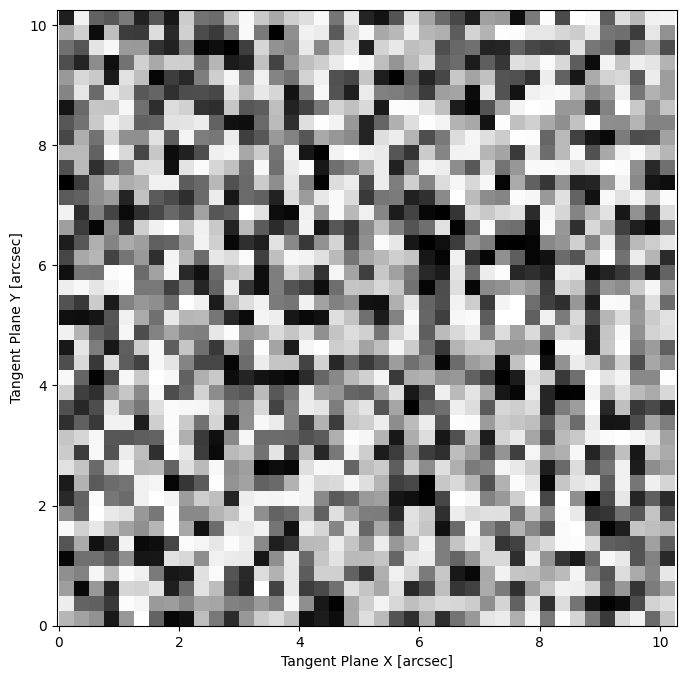

In [134]:
#Make a target
try:
    pixelscale = abs(hdu[0].header['CD2_2']) * 3600 
except KeyError:
    try:
        pixelscale = hdu[0].header['CDELT2'] * 3600 
    except KeyError:
        pixelscale = 0.258 
target = ap.image.Target_Image(
    data=target_data,
    pixelscale=pixelscale,
    variance=np.ones(target_data.shape) / 1e3
)

fig3, ax3 = plt.subplots(figsize=(8, 8))
ap.plots.target_image(fig3, ax3, target)
plt.show()

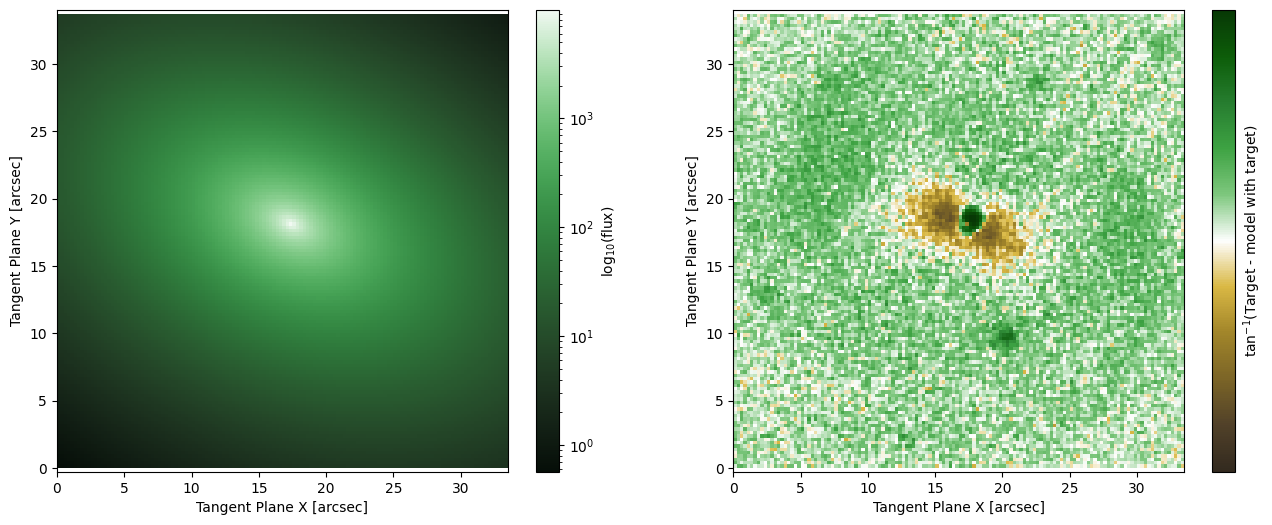

In [128]:
#Create autoprof model
model = ap.models.AstroPhot_Model(
    name = "model with target", 
    model_type = "sersic galaxy model",   
    target = target,
)

model.initialize()

fig1, ax1 = plt.subplots(1, 2, figsize = (16,6))
ap.plots.model_image(fig1, ax1[0], model)
ap.plots.residual_image(fig1, ax1[1], model)
plt.show()

In [129]:
#Print fitting result
result = ap.fit.LM(model, verbose = 1).fit()
print("Fit message:",result.message)

Chi^2/DoF: 51789963.01966016, L: 1.0
Chi^2/DoF: 44377608.52887025, L: 0.1111111111111111
Chi^2/DoF: 39572094.130118005, L: 0.0013717421124828531
Chi^2/DoF: 37053412.57373983, L: 0.00015241579027587256
Chi^2/DoF: 30241097.47369767, L: 0.00018628596589273313
Chi^2/DoF: 24714019.64944107, L: 0.00022768284720222937
Chi^2/DoF: 23814687.01658272, L: 0.00027827903546939146
Chi^2/DoF: 23640012.71028736, L: 0.00034011882112925626
Chi^2/DoF: 23572274.36689846, L: 0.0004157007813802021
Chi^2/DoF: 23534921.355798624, L: 0.0005080787327980248
Chi^2/DoF: 23511462.35878705, L: 0.0006209851178642525
Chi^2/DoF: 23499630.740759287, L: 6.89983464293614e-05
Chi^2/DoF: 23415760.595730245, L: 8.433131230255283e-05
Chi^2/DoF: 23402941.931329418, L: 0.00010307160392534234
Chi^2/DoF: 23399640.888999324, L: 0.00012597640479764064
Chi^2/DoF: 23397511.354392808, L: 0.20493561584913966
Chi^2/DoF: 23396474.280471515, L: 0.00028111881460787336
Chi^2/DoF: 23394284.134554606, L: 3.123542384531926e-05
Chi^2/DoF: 233942

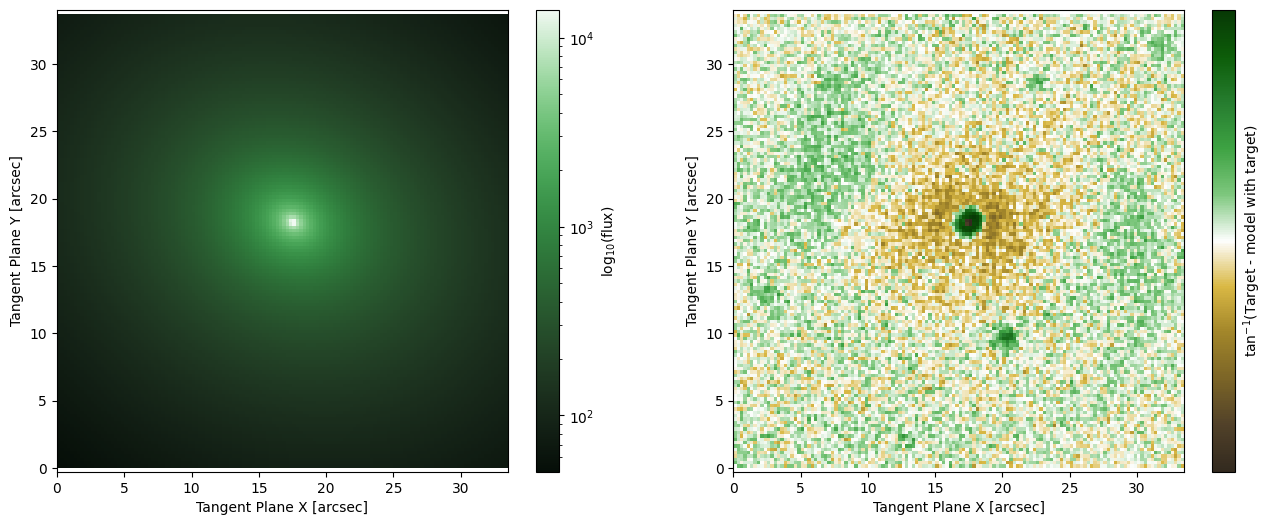

In [130]:
#Plot the model image and residual image
fig2, ax2 = plt.subplots(1, 2, figsize = (16,6))
ap.plots.model_image(fig2, ax2[0], model)
ap.plots.residual_image(fig2, ax2[1], model)
model_img = model()
plt.show()

In [131]:
#Save model data
q =  model["q"].value.item()
print(q)
#Compute inclination angle
inclination_angle = np.degrees(np.arccos(q))
print(FRB_name,"inclination angle : ", inclination_angle)
error_q = model["q"].uncertainty.item()
print(FRB_name,"error of q : ", error_q)
#Compute error of inclination angle
error_i = 1/np.sqrt(1-q**2*error_q)
print(FRB_name,"error of i : ",error_i)
print("\n",inclination_angle," +- ", error_i)

print(model["PA"].value.item(), model["n"].value.item())

0.8312540579682699
20220319D_flux.fits inclination angle :  33.77222359939497
20220319D_flux.fits error of q :  0.03
20220319D_flux.fits error of i :  1.0105287267986498

 33.77222359939497  +-  1.0105287267986498
1.135368424857052 5.321419242394721


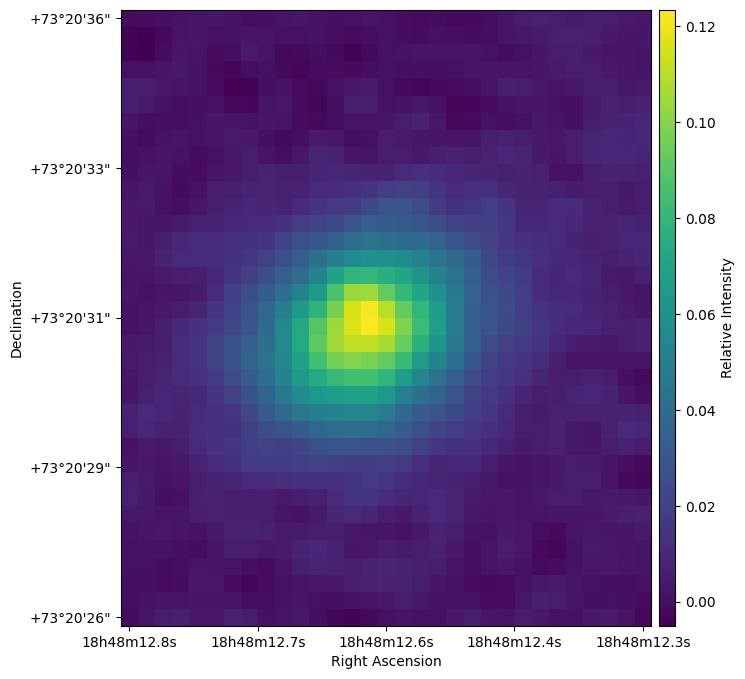

In [35]:
#Plot the target image in a given format
import matplotlib.pyplot as plt
from astropy.io import fits

def deg2hms(ra_deg):
    """Convert RA from degrees to h:m:s string."""
    ra_hour = ra_deg / 15
    h = int(ra_hour)
    m = int((ra_hour - h) * 60)
    s = (((ra_hour - h) * 60 - m) * 60)  # Cast to int to truncate the float to its integer part
    return "{:02d}h{:02d}m{:0.1f}s".format(h,m, s)

def deg2dms(dec_deg):
    """Convert declination from degrees to ° ' " format."""
    sign = "+" if dec_deg >= 0 else "-"
    dec_abs = abs(dec_deg)
    d = int(dec_abs)
    m = int((dec_abs - d) * 60)
    s = int((dec_abs - d - m/60.) * 3600)  # Cast to int to truncate the float to its integer part
    return "{}{:02d}°{:02d}'{:02d}\"".format(sign, d, m, s)

galaxy_data = hdu[0].data

fig3, ax3 = plt.subplots(figsize=(8, 8))
display = ax3.imshow(galaxy_data, cmap='viridis', origin='lower')

pos = ax3.get_position()
cax = fig3.add_axes([pos.x1+0.01, pos.y0, 0.02, pos.height])  # [left, bottom, width, height]
cbar = fig3.colorbar(display, cax=cax, label="Relative Intensity")

# Customize x-axis (Right Ascension) tick labels
x_ticks = np.linspace(0, galaxy_data.shape[1]-1, 5)  # Adjust the number of ticks as needed
ra_values = [header['CRVAL1'] + header['CD1_1'] * (tick - header['CRPIX1']) for tick in x_ticks]
ra_labels = [deg2hms(ra) for ra in ra_values]


ax3.set_xticks(x_ticks)
ax3.set_xticklabels(ra_labels, fontsize=10)

# Customize y-axis (Declination) tick labels
y_ticks = np.linspace(0, galaxy_data.shape[0]-1, 5)
dec_values = [header['CRVAL2'] + header['CD2_2'] * (tick - header['CRPIX2']) for tick in y_ticks]
dec_labels = [deg2dms(dec) for dec in dec_values]

ax3.set_yticks(y_ticks)
ax3.set_yticklabels(dec_labels, fontsize=10)

ax3.set_xlabel('Right Ascension')
ax3.set_ylabel('Declination')
ax3.grid(False)

plt.show()

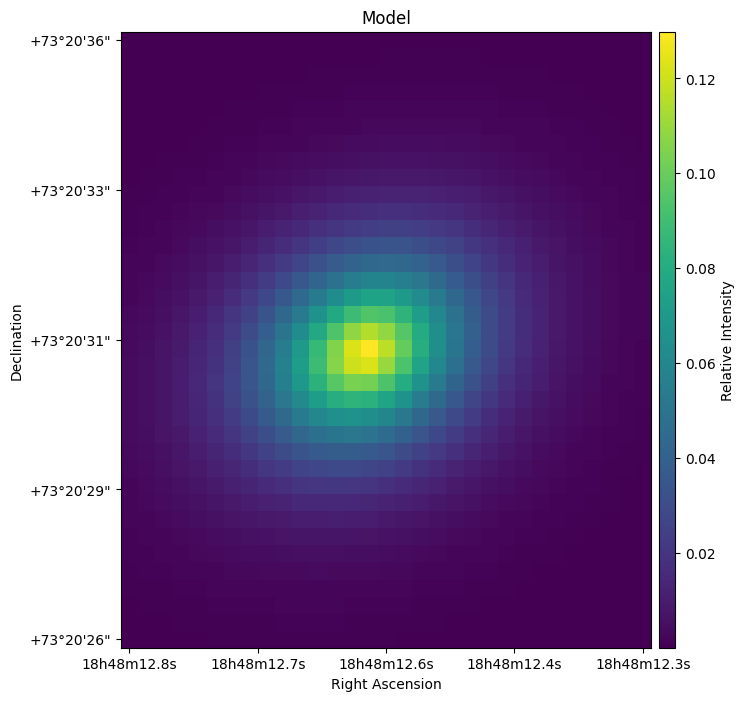

In [36]:
#Plot the model image in a given format
model_data = model_img.data

fig3, ax3 = plt.subplots(figsize=(8, 8))
display = ax3.imshow(model_data, cmap='viridis', origin='lower')

pos = ax3.get_position()
cax = fig3.add_axes([pos.x1+0.01, pos.y0, 0.02, pos.height])  # [left, bottom, width, height]
cbar = fig3.colorbar(display, cax=cax, label="Relative Intensity")

ax3.set_title("Model")

# Customize x-axis (Right Ascension) tick labels
x_ticks = np.linspace(0, model_data.shape[1]-1, 5)  # Adjust the number of ticks as needed
ra_values = [header['CRVAL1'] + header['CD1_1'] * (tick - header['CRPIX1']) for tick in x_ticks]
ra_labels = [deg2hms(ra) for ra in ra_values]

# Reverse the order of x-axis tick labels to make them bigger to smaller
#ra_labels = ra_labels[::-1]

ax3.set_xticks(x_ticks)
ax3.set_xticklabels(ra_labels, fontsize=10)

# Customize y-axis (Declination) tick labels
y_ticks = np.linspace(0, model_data.shape[0]-1, 5)
dec_values = [header['CRVAL2'] + header['CD2_2'] * (tick - header['CRPIX2']) for tick in y_ticks]
dec_labels = [deg2dms(dec) for dec in dec_values]

ax3.set_yticks(y_ticks)
ax3.set_yticklabels(dec_labels, fontsize=10)

ax3.set_xlabel('Right Ascension')
ax3.set_ylabel('Declination')
ax3.grid(False)

plt.show()

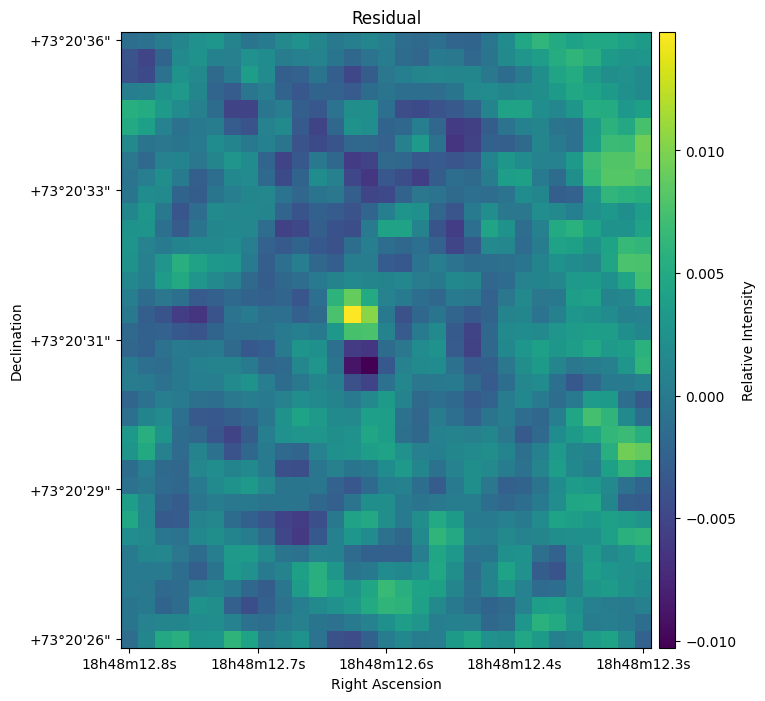

In [37]:
#Plot the residual image in a given format
residual_data = target.data - model_img.data

fig3, ax3 = plt.subplots(figsize=(8, 8))
display = ax3.imshow(residual_data, cmap='viridis', origin='lower')

pos = ax3.get_position()
cax = fig3.add_axes([pos.x1+0.01, pos.y0, 0.02, pos.height])  # [left, bottom, width, height]
cbar = fig3.colorbar(display, cax=cax, label="Relative Intensity")

ax3.set_title("Residual")

# Customize x-axis (Right Ascension) tick labels
x_ticks = np.linspace(0, residual_data.shape[1]-1, 5)  # Adjust the number of ticks as needed
ra_values = [header['CRVAL1'] + header['CD1_1'] * (tick - header['CRPIX1']) for tick in x_ticks]
ra_labels = [deg2hms(ra) for ra in ra_values]

# Reverse the order of x-axis tick labels to make them bigger to smaller
#ra_labels = ra_labels[::-1]

ax3.set_xticks(x_ticks)
ax3.set_xticklabels(ra_labels, fontsize=10)

# Customize y-axis (Declination) tick labels
y_ticks = np.linspace(0, residual_data.shape[0]-1, 5)
dec_values = [header['CRVAL2'] + header['CD2_2'] * (tick - header['CRPIX2']) for tick in y_ticks]
dec_labels = [deg2dms(dec) for dec in dec_values]

ax3.set_yticks(y_ticks)
ax3.set_yticklabels(dec_labels, fontsize=10)

ax3.set_xlabel('Right Ascension')
ax3.set_ylabel('Declination')
ax3.grid(False)

plt.show()

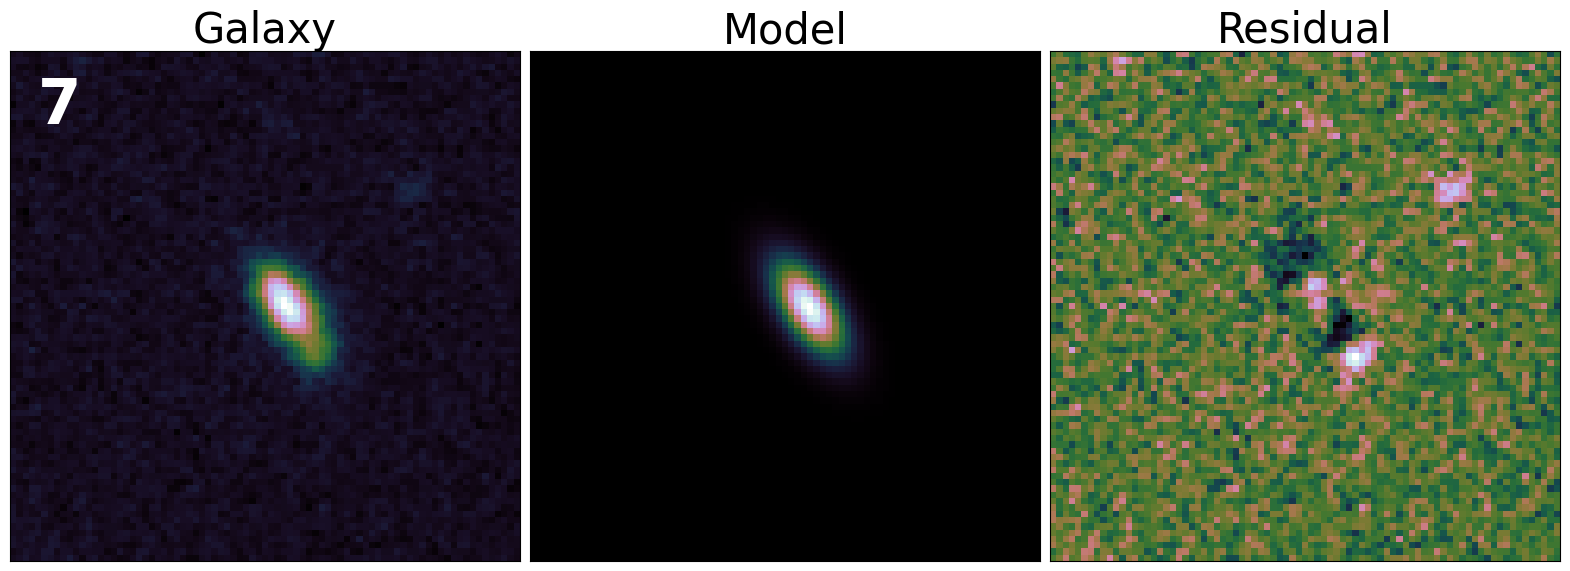

In [13]:
#Plot the final plot of FRB host galaxy modeling
fig, ax = plt.subplots(1, 3, figsize=(20, 7))

# Plot Galaxy Data
ax[0].imshow(galaxy_data, cmap='cubehelix', origin='lower')
ax[0].set_title("Galaxy", fontsize = 30)
ax[0].set_xticks([])  # Removing x-axis ticks
ax[0].set_yticks([])  # Removing y-axis ticks

# Plot Model Data
ax[1].imshow(model_data, cmap='cubehelix', origin='lower')
ax[1].set_title("Model", fontsize = 30)
ax[1].set_xticks([])  # Removing x-axis ticks
ax[1].set_yticks([])  # Removing y-axis ticks

# Plot Residual Data
ax[2].imshow(residual_data, cmap='cubehelix', origin='lower')
ax[2].set_title("Residual", fontsize = 30)
ax[2].set_xticks([])  # Removing x-axis ticks
ax[2].set_yticks([])  # Removing y-axis ticks
plt.subplots_adjust(wspace=0.02)
# Common settings for all plots (Optional, for aesthetics)
for a in ax:
    a.set_xlabel('')  # Remove x-axis label if any
    a.set_ylabel('')  # Remove y-axis label if any
    a.grid(False)  # Disable grid if it's enabled

mid_x = 0.15
mid_y = 0.78
plt.text(mid_x, mid_y, '7', horizontalalignment='center', verticalalignment='center', transform=plt.gcf().transFigure, color='white', fontsize=45, fontweight='bold')
plt.savefig("FRB_name.eps", bbox_inches="tight",dpi=300)
plt.show()